# 深度 EDA：按时段拆解出价日志

48 ticks → 6 个自然时段:
- 深夜 (0-7,   00:00-04:00)  
- 凌晨 (8-15,  04:00-08:00)  
- 上午 (16-23, 08:00-12:00)  
- 下午 (24-31, 12:00-16:00)  
- 晚高峰(32-39, 16:00-20:00)  
- 晚间 (40-47, 20:00-24:00)

目标：发现 tick 级的时间模式 + period 间的日期差异 → 为自然语言场景定义提供数据依据

In [1]:
import pandas as pd
import numpy as np
import os
import json
from collections import defaultdict

DATA_DIR = "D:/research/Experiment/autobidding/data/MDP/traffic"
PERIODS = [8, 9, 10, 11, 12]  # skip 7 (damaged)
CHUNK_SIZE = 300000

def get_phase(tick):
    if tick <= 7:   return '深夜(00-04)'
    if tick <= 15:  return '凌晨(04-08)'
    if tick <= 23:  return '上午(08-12)'
    if tick <= 31:  return '下午(12-16)'
    if tick <= 39:  return '晚高峰(16-20)'
    return '晚间(20-24)'

PHASES = ['深夜(00-04)','凌晨(04-08)','上午(08-12)','下午(12-16)','晚高峰(16-20)','晚间(20-24)']
print('Ready. Periods:', PERIODS)

Ready. Periods: [8, 9, 10, 11, 12]


## 1. 按时段聚合 — 单 Period 演示 (period 9)

In [2]:
def process_one_period(csv_path, period_id):
    """读取一个 period 的 CSV，按时段聚合统计。"""
    # per-phase accumulators
    acc = {p: {'pv_set': set(), 'n': 0,
               'pValue': [], 'lwc': [], 'bid_pos': [],
               'xi': 0, 'exposed': 0, 'conv': 0, 'cost_win': []}
           for p in PHASES}
    
    for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=CHUNK_SIZE)):
        if i % 20 == 0:
            print(f'  chunk {i}... ({i*CHUNK_SIZE/1e6:.1f}M rows)', flush=True)
        for _, row in chunk.iterrows():
            tick = int(row['timeStepIndex'])
            phase = get_phase(tick)
            a = acc[phase]
            a['n'] += 1
            a['pv_set'].add(int(row['pvIndex']))
            a['pValue'].append(row['pValue'])
            a['lwc'].append(row['leastWinningCost'])
            if row['bid'] > 0:
                a['bid_pos'].append(row['bid'])
            a['xi'] += row['xi']
            a['exposed'] += row['isExposed']
            a['conv'] += row['conversionAction']
            if row['isExposed'] > 0 and row['cost'] > 0:
                a['cost_win'].append(row['cost'])
    
    rows = []
    for phase, a in acc.items():
        pv = np.array(a['pValue'])
        lwc = np.array(a['lwc'])
        bid = np.array(a['bid_pos'])
        cw = np.array(a['cost_win'])
        rows.append({
            'period': period_id, 'phase': phase,
            'pv_count': len(a['pv_set']),
            'pValue_mean': pv.mean(), 'pValue_std': pv.std(),
            'pValue_p50': np.median(pv), 'pValue_p90': np.percentile(pv,90),
            'leastWinCost_mean': lwc.mean(), 'leastWinCost_p50': np.median(lwc),
            'leastWinCost_p90': np.percentile(lwc,90),
            'bid_mean': bid.mean() if len(bid)>0 else 0,
            'win_rate': a['xi']/a['n'], 
            'exposed_rate': a['exposed']/a['n'],
            'conv_rate': a['conv']/a['n'],
            'cost_per_win': cw.mean() if len(cw)>0 else 0,
        })
    return rows

# 先跑一个 period 看看
rows_p9 = process_one_period(f'{DATA_DIR}/period-9.csv', 9)
df_p9 = pd.DataFrame(rows_p9)
df_p9.set_index('phase', inplace=True)
df_p9

  chunk 0... (0.0M rows)
  chunk 20... (6.0M rows)
  chunk 40... (12.0M rows)
  chunk 60... (18.0M rows)


,period,pv_count,pValue_mean,pValue_std,pValue_p50,pValue_p90,leastWinCost_mean,leastWinCost_p50,leastWinCost_p90,bid_mean,win_rate,exposed_rate,conv_rate,cost_per_win
phase,,,,,,,,,,,,,,
深夜(00-04),9,11112,0.000543,0.000347,0.000490,0.001018,0.108921,0.105558,0.147983,0.046836,0.0625,0.047568,0.000059,0.132988
凌晨(04-08),9,10158,0.000487,0.000374,0.000392,0.001007,0.104670,0.103780,0.121976,0.047673,0.0625,0.047564,0.000067,0.117411
上午(08-12),9,26662,0.000652,0.000389,0.000607,0.001157,0.104329,0.100173,0.130179,0.058032,0.0625,0.047443,0.000062,0.116845
下午(12-16),9,11696,0.000325,0.000225,0.000280,0.000631,0.058966,0.058275,0.069532,0.031033,0.0625,0.047635,0.000032,0.067992
晚高峰(16-20),9,11652,0.000574,0.000402,0.000491,0.001120,0.110158,0.108535,0.131886,0.056823,0.0625,0.047604,0.000068,0.124799
晚间(20-24),9,16866,0.000364,0.000278,0.000295,0.000747,0.063977,0.061704,0.080287,0.032960,0.0625,0.047584,0.000039,0.073342


## 2. 全部 5 个 Period (8-12) 逐时段聚合

In [3]:
all_rows = []
for p in PERIODS:
    path = f'{DATA_DIR}/period-{p}.csv'
    if not os.path.exists(path):
        print(f'SKIP: {path}')
        continue
    print(f'Period {p}...')
    all_rows.extend(process_one_period(path, p))

df = pd.DataFrame(all_rows)
print(f'\nTotal: {len(df)} rows (6 phases × {len(df)//6} periods)')
df.head(12)

Period 8...
  chunk 0... (0.0M rows)
  chunk 20... (6.0M rows)
  chunk 40... (12.0M rows)
  chunk 60... (18.0M rows)
Period 9...
  chunk 0... (0.0M rows)
  chunk 20... (6.0M rows)
  chunk 40... (12.0M rows)
  chunk 60... (18.0M rows)
Period 10...
  chunk 0... (0.0M rows)
  chunk 20... (6.0M rows)
  chunk 40... (12.0M rows)
  chunk 60... (18.0M rows)
Period 11...
  chunk 0... (0.0M rows)
  chunk 20... (6.0M rows)
  chunk 40... (12.0M rows)
  chunk 60... (18.0M rows)
Period 12...
  chunk 0... (0.0M rows)
  chunk 20... (6.0M rows)
  chunk 40... (12.0M rows)
  chunk 60... (18.0M rows)

Total: 30 rows (6 phases × 5 periods)


,period,phase,pv_count,pValue_mean,pValue_std,pValue_p50,pValue_p90,leastWinCost_mean,leastWinCost_p50,leastWinCost_p90,bid_mean,win_rate,exposed_rate,conv_rate,cost_per_win
0,8,深夜(00-04),10849,0.004642,0.003372,0.003864,0.008948,0.118383,0.116453,0.143871,0.053015,0.0625,0.047350,0.000483,0.142199
1,8,凌晨(04-08),19865,0.005372,0.004031,0.004278,0.011066,0.107957,0.101552,0.142591,0.052566,0.0625,0.047533,0.000499,0.122590
2,8,上午(08-12),18648,0.005668,0.004199,0.004591,0.011452,0.099199,0.094240,0.129358,0.046903,0.0625,0.047495,0.000609,0.115135
3,8,下午(12-16),16190,0.005486,0.004090,0.004506,0.011073,0.093303,0.090870,0.114436,0.045805,0.0625,0.047588,0.000569,0.107440
4,8,晚高峰(16-20),10606,0.004918,0.003037,0.004425,0.009036,0.083491,0.082499,0.098448,0.043962,0.0625,0.047544,0.000454,0.095089
5,8,晚间(20-24),16829,0.005637,0.003607,0.004963,0.010550,0.096661,0.095575,0.115337,0.055602,0.0625,0.047567,0.000505,0.108327
6,9,深夜(00-04),11112,0.000543,0.000347,0.000490,0.001018,0.108921,0.105558,0.147983,0.046836,0.0625,0.047568,0.000059,0.132988
7,9,凌晨(04-08),10158,0.000487,0.000374,0.000392,0.001007,0.104670,0.103780,0.121976,0.047673,0.0625,0.047564,0.000067,0.117411
8,9,上午(08-12),26662,0.000652,0.000389,0.000607,0.001157,0.104329,0.100173,0.130179,0.058032,0.0625,0.047443,0.000062,0.116845
9,9,下午(12-16),11696,0.000325,0.000225,0.000280,0.000631,0.058966,0.058275,0.069532,0.031033,0.0625,0.047635,0.000032,0.067992


## 3. 时段画像：5 个 Period 的均值

In [4]:
phase_avg = df.groupby('phase')[['pv_count','pValue_mean','pValue_p50',
    'leastWinCost_mean','leastWinCost_p50','leastWinCost_p90',
    'bid_mean','win_rate','conv_rate','cost_per_win']].mean().round(6)

# 按时间顺序排列
phase_avg = phase_avg.loc[PHASES]
phase_avg

,pv_count,pValue_mean,pValue_p50,leastWinCost_mean,leastWinCost_p50,leastWinCost_p90,bid_mean,win_rate,conv_rate,cost_per_win
phase,,,,,,,,,,
深夜(00-04),11991.6,0.001308,0.001097,0.106493,0.097169,0.156693,0.045136,0.0625,0.000137,0.149521
凌晨(04-08),12573.0,0.001456,0.001180,0.099316,0.096924,0.120764,0.047607,0.0625,0.000144,0.114568
上午(08-12),19712.4,0.001597,0.001321,0.100983,0.098340,0.122794,0.051846,0.0625,0.000171,0.113654
下午(12-16),14287.0,0.001489,0.001236,0.090242,0.087941,0.110953,0.045643,0.0625,0.000154,0.103468
晚高峰(16-20),14925.6,0.001419,0.001267,0.088549,0.086728,0.106995,0.047859,0.0625,0.000138,0.099993
晚间(20-24),17332.0,0.001517,0.001330,0.077156,0.075550,0.093888,0.042762,0.0625,0.000138,0.087365


C:\Users\22397\AppData\Local\Temp\ipykernel_87324\372149758.py:22: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\22397\AppData\Local\Temp\ipykernel_87324\372149758.py:22: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\22397\AppData\Local\Temp\ipykernel_87324\372149758.py:22: UserWarning: Glyph 20940 (\N{CJK UNIFIED IDEOGRAPH-51CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\22397\AppData\Local\Temp\ipykernel_87324\372149758.py:22: UserWarning: Glyph 26216 (\N{CJK UNIFIED IDEOGRAPH-6668}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\22397\AppData\Local\Temp\ipykernel_87324\372149758.py:22: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\22397\AppData\Local\Temp\ipykernel_87324\372149758.py:22: UserWarning: Glyph 21320 (\N{CJK 

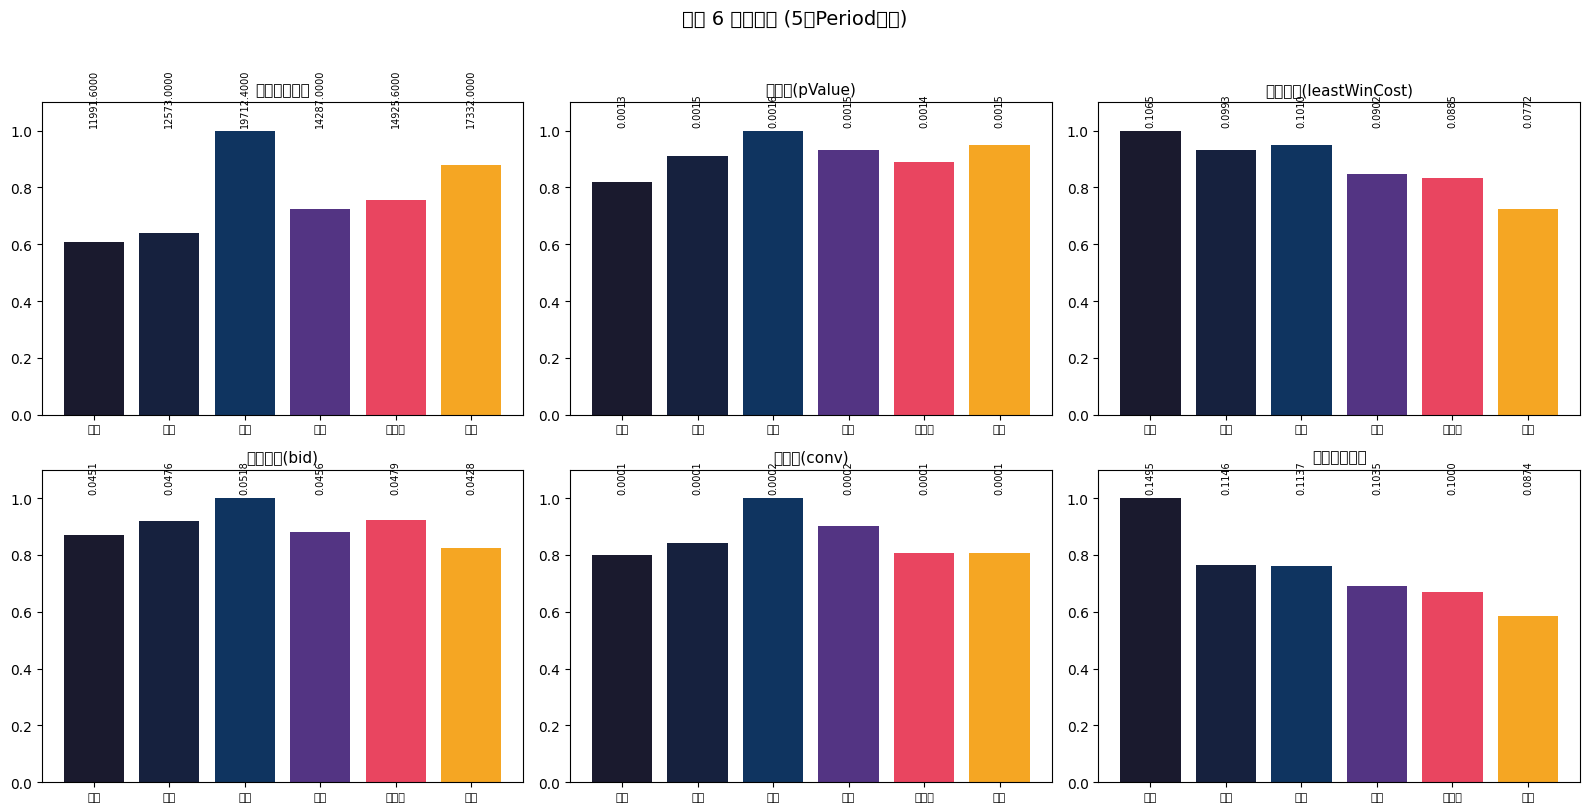

In [5]:
# 归一化对比（相对值更容易看模式）
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = ['pv_count','pValue_mean','leastWinCost_mean','bid_mean','conv_rate','cost_per_win']
titles = ['日间流量分布','转化率(pValue)','竞争水位(leastWinCost)',
          '出价水位(bid)','转化率(conv)','每次获胜成本']

for ax, metric, title in zip(axes.flat, metrics, titles):
    vals = phase_avg[metric].values
    vals_norm = vals / vals.max()  # 归一化到 [0,1]
    ax.bar(range(6), vals_norm, color=['#1a1a2e','#16213e','#0f3460','#533483','#e94560','#f5a623'])
    ax.set_xticks(range(6))
    ax.set_xticklabels(['深夜','凌晨','上午','下午','晚高峰','晚间'], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.1)
    # 标注实际值
    for i, v in enumerate(vals):
        ax.text(i, 1.02, f'{v:.4f}', ha='center', fontsize=7, rotation=90)

plt.suptitle('一日 6 时段画像 (5个Period均值)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Period 8 (高转化日) vs Period 9-12 (普通日)

In [6]:
p8 = df[df['period']==8]
pnorm = df[df['period'].isin([9,10,11,12])]

print('='*80)
print('Period 8 vs 普通日 — 全时段均值对比')
print('='*80)
for col in ['pValue_mean','leastWinCost_mean','bid_mean','conv_rate','cost_per_win']:
    v8 = p8[col].mean()
    vn = pnorm[col].mean()
    ratio = v8/max(vn,1e-10)
    bar = '█' * int(ratio*10)
    print(f'  {col:25s}: P8={v8:.6f}  Normal={vn:.6f}  ratio={ratio:.2f}x {bar}')

Period 8 vs 普通日 — 全时段均值对比
  pValue_mean              : P8=0.005287  Normal=0.000509  ratio=10.40x ███████████████████████████████████████████████████████████████████████████████████████████████████████
  leastWinCost_mean        : P8=0.099832  Normal=0.092279  ratio=1.08x ██████████
  bid_mean                 : P8=0.049642  Normal=0.046100  ratio=1.08x ██████████
  conv_rate                : P8=0.000520  Normal=0.000054  ratio=9.67x ████████████████████████████████████████████████████████████████████████████████████████████████
  cost_per_win             : P8=0.115130  Normal=0.110503  ratio=1.04x ██████████


In [7]:
# 逐时段对比：Period 8 的高转化是全天均匀还是集中在某时段？
print('='*80)
print('Period 8 vs 普通日 — 逐时段 pValue 对比')
print('='*80)
for phase in PHASES:
    v8 = p8[p8['phase']==phase]['pValue_mean'].values
    vn = pnorm[pnorm['phase']==phase]['pValue_mean'].values
    if len(v8)>0 and len(vn)>0:
        v8, vn = v8[0], vn.mean()
        ratio = v8/max(vn,1e-10)
        bar = '█' * int(ratio)
        print(f'  {phase:18s}: P8={v8:.6f}  Normal={vn:.6f}  ratio={ratio:.1f}x {bar}')

print('\n=== 逐时段 leastWinCost 对比 ===')
for phase in PHASES:
    v8 = p8[p8['phase']==phase]['leastWinCost_mean'].values
    vn = pnorm[pnorm['phase']==phase]['leastWinCost_mean'].values
    if len(v8)>0 and len(vn)>0:
        v8, vn = v8[0], vn.mean()
        ratio = v8/max(vn,1e-10)
        print(f'  {phase:18s}: P8={v8:.4f}  Normal={vn:.4f}  ratio={ratio:.2f}x')

Period 8 vs 普通日 — 逐时段 pValue 对比
  深夜(00-04)         : P8=0.004642  Normal=0.000474  ratio=9.8x █████████
  凌晨(04-08)         : P8=0.005372  Normal=0.000477  ratio=11.3x ███████████
  上午(08-12)         : P8=0.005668  Normal=0.000579  ratio=9.8x █████████
  下午(12-16)         : P8=0.005486  Normal=0.000490  ratio=11.2x ███████████
  晚高峰(16-20)        : P8=0.004918  Normal=0.000545  ratio=9.0x █████████
  晚间(20-24)         : P8=0.005637  Normal=0.000487  ratio=11.6x ███████████

=== 逐时段 leastWinCost 对比 ===
  深夜(00-04)         : P8=0.1184  Normal=0.1035  ratio=1.14x
  凌晨(04-08)         : P8=0.1080  Normal=0.0972  ratio=1.11x
  上午(08-12)         : P8=0.0992  Normal=0.1014  ratio=0.98x
  下午(12-16)         : P8=0.0933  Normal=0.0895  ratio=1.04x
  晚高峰(16-20)        : P8=0.0835  Normal=0.0898  ratio=0.93x
  晚间(20-24)         : P8=0.0967  Normal=0.0723  ratio=1.34x


## 5. 日内变化幅度：哪个时段最不稳定？

In [8]:
print('='*80)
print('各时段在 5 个 Period 间的波动范围 (稳定性分析)')
print('='*80)
for phase in PHASES:
    pd_phase = df[df['phase']==phase]
    print(f'\n[{phase}]')
    for col in ['pv_count','pValue_mean','leastWinCost_mean','conv_rate']:
        vals = pd_phase[col]
        print(f'  {col:20s}: {vals.min():.6f} ~ {vals.max():.6f}  (range={vals.max()-vals.min():.6f}, cv={vals.std()/max(vals.mean(),1e-10):.2f})')

各时段在 5 个 Period 间的波动范围 (稳定性分析)

[深夜(00-04)]
  pv_count            : 10004.000000 ~ 15063.000000  (range=5059.000000, cv=0.17)
  pValue_mean         : 0.000302 ~ 0.004642  (range=0.004339, cv=1.43)
  leastWinCost_mean   : 0.074839 ~ 0.131770  (range=0.056932, cv=0.20)
  conv_rate           : 0.000042 ~ 0.000483  (range=0.000441, cv=1.42)

[凌晨(04-08)]
  pv_count            : 8654.000000 ~ 19865.000000  (range=11211.000000, cv=0.35)
  pValue_mean         : 0.000425 ~ 0.005372  (range=0.004947, cv=1.50)
  leastWinCost_mean   : 0.092160 ~ 0.107957  (range=0.015797, cv=0.07)
  conv_rate           : 0.000047 ~ 0.000499  (range=0.000453, cv=1.38)

[上午(08-12)]
  pv_count            : 16541.000000 ~ 26662.000000  (range=10121.000000, cv=0.20)
  pValue_mean         : 0.000465 ~ 0.005668  (range=0.005203, cv=1.43)
  leastWinCost_mean   : 0.084697 ~ 0.112614  (range=0.027917, cv=0.10)
  conv_rate           : 0.000047 ~ 0.000609  (range=0.000562, cv=1.43)

[下午(12-16)]
  pv_count            : 11696.0

## 6. 自然语言观察总结

In [9]:
print('='*80)
print('基于数据的自然语言观察')
print('='*80)

# 流量节奏
peak_pv = phase_avg['pv_count'].idxmax()
trough_pv = phase_avg['pv_count'].idxmin()
ratio_pv = phase_avg.loc[peak_pv,'pv_count'] / max(phase_avg.loc[trough_pv,'pv_count'],1)
print(f'\n1. 日间流量节奏:')
print(f'   全天流量高峰在「{peak_pv}」，低谷在「{trough_pv}」')
print(f'   峰谷比 = {ratio_pv:.1f}x')

# 竞争规律
peak_comp = phase_avg['leastWinCost_mean'].idxmax()
trough_comp = phase_avg['leastWinCost_mean'].idxmin()
ratio_comp = phase_avg.loc[peak_comp,'leastWinCost_mean'] / max(phase_avg.loc[trough_comp,'leastWinCost_mean'],1e-10)
print(f'\n2. 竞争水位:')
print(f'   竞争最激烈在「{peak_comp}」，最温和在「{trough_comp}」')
print(f'   峰谷比 = {ratio_comp:.2f}x')

# 转化规律
peak_conv = phase_avg['conv_rate'].idxmax()
print(f'\n3. 转化效率:')
print(f'   转化率最高在「{peak_conv}」')

# 日期差异
pv_ratio_all = p8['pValue_mean'].mean() / max(pnorm['pValue_mean'].mean(), 1e-10)
lwc_ratio_all = p8['leastWinCost_mean'].mean() / max(pnorm['leastWinCost_mean'].mean(), 1e-10)
print(f'\n4. 日期差异 (Period 8 = 高转化投放日):')
print(f'   pValue 是普通日的 {pv_ratio_all:.1f} 倍')
print(f'   leastWinCost 是普通日的 {lwc_ratio_all:.2f} 倍')
print(f'   → 转化质量显著偏高，竞争水位变化不大 → "优质流量日"')

# 普通日之间的波动
print(f'\n5. 普通日 (period 9-12) 之间的波动:')
for col in ['pValue_mean','leastWinCost_mean']:
    vals = pnorm.groupby('period')[col].mean()
    print(f'   {col}: {vals.min():.6f} ~ {vals.max():.6f} (cv={vals.std()/vals.mean():.2f})')

基于数据的自然语言观察

1. 日间流量节奏:
   全天流量高峰在「上午(08-12)」，低谷在「深夜(00-04)」
   峰谷比 = 1.6x

2. 竞争水位:
   竞争最激烈在「深夜(00-04)」，最温和在「晚间(20-24)」
   峰谷比 = 1.38x

3. 转化效率:
   转化率最高在「上午(08-12)」

4. 日期差异 (Period 8 = 高转化投放日):
   pValue 是普通日的 10.4 倍
   leastWinCost 是普通日的 1.08 倍
   → 转化质量显著偏高，竞争水位变化不大 → "优质流量日"

5. 普通日 (period 9-12) 之间的波动:
   pValue_mean: 0.000491 ~ 0.000532 (cv=0.04)
   leastWinCost_mean: 0.090090 ~ 0.095370 (cv=0.02)
